# Englacial temperature profiles

A Python notebook that generates interpolated englacial temperature profiles using bedrock picks from GPR data, and marks the locations of borehole measurements on these profiles.

## Import necessary Libraries and Moudules

In [1]:
import sys

# Add project root to Python path
project_root = '/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import gpr_processing as gpr
import gpr_plotting as gprp
import cmcrameri.cm as cmc

from processing.thermistor_processing import *

## Preprocessing

### Set directions to thermistor data

In [2]:
# set main gpr data dir
root_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/gpr/"

# set main icetemp data dir
gp_icetemp_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/thermistor_chains/temperature_data/"
TT_icetemp_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/NTC_tynitag/temperature_data/full_timeseries/"

# set path to current depth file
depth_AH1G = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_ah1g.csv"
depth_AH2G = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_ah2g.csv"
depth_AH3G = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_ah3g.csv"
depth_AH1TT = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_ah1tt.csv"
depth_AH2TT = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_ah2tt.csv"
depth_AH3TT = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_ah3tt.csv"

depth_CJ1G = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_cj1g.csv"
depth_CJ2G = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_cj2g.csv"
depth_CJ1TT = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_cj1tt.csv"
depth_CJ2TT = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_cj2tt.csv"
depth_CJ3TT = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_cj3tt.csv"
depth_CJ4TT = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_cj4tt.csv"

depth_HS1G = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_hs1g.csv"
depth_HS2G = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_hs2g.csv"
depth_HS3G = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_hs3g.csv"
depth_HS1TT = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_hs1tt.csv"
depth_HS2TT = gp_icetemp_dir + "../../thermistor_borehole_settings/thermistor_settings_hs2tt.csv"

# set chain data dir
A551FE_dir = gp_icetemp_dir + "A551FE/raw/A551FE_20250916075641.csv" # AH1G
A55204_dir = gp_icetemp_dir + "A55204/raw/A55204_20250916082002.csv" # AH2G
A55205_dir = gp_icetemp_dir + "A55205/raw/A55205_20250916074654.csv" # AH3G
A551FD_dir = gp_icetemp_dir + "A551FD/raw/A551FD_20250927153221.csv" # HS1G
A55203_dir = gp_icetemp_dir + "A55203/raw/A55203_20250927151514.csv" # HS2G
A55200_dir = gp_icetemp_dir + "A55200/raw/A55200_20250927151301.csv" # HS3G
A55201_dir = gp_icetemp_dir + "A55201/raw/A55201_20250819105833.csv" # CJ1G
A55202_dir = gp_icetemp_dir + "A55202/raw/A55202_20250819111557.csv" # CJ2G

# set tiny tag data dir
AH3TT_dir = TT_icetemp_dir + "AH3TT_20241021_20250805.csv"
CJ1TT_dir = TT_icetemp_dir + "CJ1TT_20240809_20250808_spliced.csv"
CJ2TT_dir = TT_icetemp_dir + "CJ2TT_20240809_20250808_spliced.csv"
HS1TT_dir = TT_icetemp_dir + "HS1TT_20240808_20250927_spliced.csv"
HS2TT_dir = TT_icetemp_dir + "HS2TT_20240808_20250927_spliced.csv"

# generate a thermistor data object
AH1G = ThermistorData(A551FE_dir, ",", depth_AH1G)
AH2G = ThermistorData(A55204_dir, ",", depth_AH2G)
AH3G = ThermistorData(A55205_dir, ",", depth_AH3G)
AH3TT = ThermistorData(AH3TT_dir, ",", depth_AH3TT)

CJ1G = ThermistorData(A55201_dir, ",", depth_CJ1G)
CJ2G = ThermistorData(A55202_dir, ",", depth_CJ2G)
CJ1TT = ThermistorData(CJ1TT_dir, ",", depth_CJ1TT)
CJ2TT = ThermistorData(CJ2TT_dir, ",", depth_CJ2TT)

HS1G = ThermistorData(A551FD_dir, ",", depth_HS1G)
HS2G = ThermistorData(A55203_dir, ",", depth_HS2G)
HS3G = ThermistorData(A55200_dir, ",", depth_HS3G)
HS1TT = ThermistorData(HS1TT_dir, ",", depth_HS1TT)
HS2TT = ThermistorData(HS2TT_dir, ",", depth_HS2TT)

# read chain temperature offsets from CSV file
offsets_path_G = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/thermistor_calibration/corrected_chain_offsets.csv"
offsets_path_TT = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/NTC_tynitag/calibration_data/all_logger_offsets.csv"
corrected_offsets_G = pd.read_csv(offsets_path_G, index_col='chain')
corrected_offsets_TT = pd.read_csv(offsets_path_TT)

In [3]:
## Step 1. get coordinates for each borehole
bh_csv = root_dir + "../icetemperature_data/thermistor_borehole_settings/thermistor_coordinates.csv"
borehole_coordinates, bh_missing = gpr.load_borehole_positions(bh_csv)

## Step 2. get temperature data for each borehole and thermistor

# Chessjen boreholes
CJ1G_data = CJ1G.get_chain_data_with_offsets(snapshot_day='20250819', offsets=corrected_offsets_G.loc["A55201"], return_daily_average=True)
CJ2G_data = CJ2G.get_chain_data_with_offsets(snapshot_day='20250819', offsets=corrected_offsets_G.loc["A55202"], return_daily_average=True)
CJ1TT_data = CJ1TT.get_ntc_data_with_offsets('7', corrected_offsets_TT, aggregate='all') # average over entire period
CJ2TT_data = CJ2TT.get_ntc_data_with_offsets('8', corrected_offsets_TT, aggregate='all') # average over entire period

# Alphubel boreholes
AH1G_data = AH1G.get_chain_data_with_offsets(snapshot_day='20250916', offsets=corrected_offsets_G.loc["A551FE"])
AH2G_data = AH2G.get_chain_data_with_offsets(snapshot_day='20250916', offsets=corrected_offsets_G.loc["A55204"])
AH3G_data = AH3G.get_chain_data_with_offsets(snapshot_day='20250907', offsets=corrected_offsets_G.loc["A55205"])
AH3TT_data = AH3TT.get_ntc_data_with_offsets('13', corrected_offsets_TT, aggregate='all') # average over entire period

# Hohsaas boreholes
HS1G_data = HS1G.get_chain_data_with_offsets(snapshot_day='20250927', offsets=corrected_offsets_G.loc["A551FD"])
HS2G_data = HS2G.get_chain_data_with_offsets(snapshot_day='20250927', offsets=corrected_offsets_G.loc["A55203"])
HS3G_data = HS3G.get_chain_data_with_offsets(snapshot_day='20250927', offsets=corrected_offsets_G.loc["A55200"])
HS1TT_data = HS1TT.get_ntc_data_with_offsets('5', corrected_offsets_TT, aggregate='all') # average over entire period
HS2TT_data = HS2TT.get_ntc_data_with_offsets('6', corrected_offsets_TT, aggregate='all') # average over entire period

## step 3. get depths for each thermistor in the borehole

# Chessjen boreholes
CJ1G_depths = read_thermistor_depths(depth_CJ1G)
CJ2G_depths = read_thermistor_depths(depth_CJ2G)
CJ1TT_depths = read_thermistor_depths(depth_CJ1TT)
CJ2TT_depths = read_thermistor_depths(depth_CJ2TT)
CJ3TT_depths = read_thermistor_depths(depth_CJ3TT)
CJ4TT_depths = read_thermistor_depths(depth_CJ4TT)

# Alphubel boreholes
AH1G_depths = read_thermistor_depths(depth_AH1G)
AH2G_depths = read_thermistor_depths(depth_AH2G)
AH3G_depths = read_thermistor_depths(depth_AH3G)
AH3TT_depths = read_thermistor_depths(depth_AH3TT)

# Hohsaas boreholes
HS1G_depths = read_thermistor_depths(depth_HS1G)
HS2G_depths = read_thermistor_depths(depth_HS2G)
HS3G_depths = read_thermistor_depths(depth_HS3G)
HS1TT_depths = read_thermistor_depths(depth_HS1TT)
HS2TT_depths = read_thermistor_depths(depth_HS2TT)

### Round temperature data to 2 digits
Otherwise e.g. temperatures at -0.001 will be displayed as cold -> Soon needs to be improved to adjust for the melting point temperature

In [4]:
# Round temperature-like columns in a DataFrame
def round_temp_columns(df: pd.DataFrame, decimals: int = 5):
    if not isinstance(df, pd.DataFrame):
        return df
    # GeoPrecision chain columns: '#1', '#2', ... (leave TIME, NO, HK-BAT:V untouched)
    chain_cols = [c for c in df.columns if re.fullmatch(r"#\d+", str(c))]
    # TinyTag probe columns
    tt_cols = [c for c in ["Black Probe Temperature", "White Probe Temperature"] if c in df.columns]
    cols = chain_cols + tt_cols
    if cols:
        df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").round(decimals)
    return df

# Apply to all loaded datasets if present
datasets = [
    "CJ1G_data","CJ2G_data","AH1G_data","AH2G_data","AH3G_data",
    "HS1G_data","HS2G_data","HS3G_data",
    "CJ1TT_data","CJ2TT_data","HS1TT_data","HS2TT_data","AH3TT_data"
]
for name in datasets:
    df = globals().get(name)
    if isinstance(df, pd.DataFrame):
        round_temp_columns(df, 2)

### Get GPR bedrock picks and generate profiles

In [5]:
# List GPR bedrock picks files for each glacier/profile
gpr_picks_dirs = [
    root_dir + "/20250515_Alphubel/bed picks_south/20060101_GPR_picks_south.txt", # Alphubel south
    root_dir + "/20240809_Chessjen/picks/20240809_chessjen_picks_updated.csv", # Chessjen
    root_dir + "/20240808_Hohsaas/picks/20240808_hohsaas_picks.csv", # Hohsaas (if available)
]

# Build a profile table (use the raw TXT files)
df_all_AH = gpr.load_points_from_txt(gpr_picks_dirs[0], epsg=2056, drop_duplicates=True, aggregate_duplicates='mean', return_type='df')

# Choose a profile id present in df_all['profile'] (e.g., 12)
prof_id_AH = 4
prof_AH = gpr.extract_profile_table(df_all_AH, prof_id_AH, order_method="pca")

# Build a profile table for Chessjen (use the raw CSV files)
df_all_cj = gpr.load_points_from_csv(gpr_picks_dirs[1], epsg=2056, source_epsg=32632, drop_duplicates=True, aggregate_duplicates='mean', return_type='df')

# Choose a profile id present in df_all_cj['profile'] (e.g., 47)
prof_id_cj = 47
prof_cj = gpr.extract_profile_table(df_all_cj, prof_id_cj, order_method="pca")

# Build a profile table for Hohsaas (use the raw CSV files)
df_all_hs = gpr.load_points_from_csv(gpr_picks_dirs[2], epsg=2056, source_epsg=32632, drop_duplicates=True, aggregate_duplicates='mean', return_type='df')

# Choose a profile id present in df_all_hs['profile'] (e.g., 40)
prof_hs1 = gpr.extract_profile_table(df_all_hs, 39, order_method="pca")
prof_hs2 = gpr.extract_profile_table(df_all_hs, 40, order_method="pca")

## Plot Alphubel interpolated englacial temperature profile

In [6]:
# Create the input dictionaries for Alphubel
thermistor_data_AH = {
    'AH1G': AH1G_data,
    'AH2G': AH2G_data,
    'AH3G': AH3G_data,
    'AH3TT': AH3TT_data
}

depth_data_AH = {
    'AH1G': AH1G_depths,
    'AH2G': AH2G_depths,
    'AH3G': AH3G_depths,
    'AH3TT': AH3TT_depths
}

# Extract temperature and depth dictionaries
temp_data_dict_AH, depth_dict_AH = create_temp_depth_dicts(thermistor_data_AH, depth_data_AH)

AH1G: 10 thermistors
  #1: -0.450°C at 18.0 m
  #2: -0.520°C at 21.0 m
  #3: -0.130°C at 24.0 m
  #4: -0.010°C at 27.0 m
  #5: -0.220°C at 30.0 m
  #6: -0.210°C at 33.0 m
  #7: -0.360°C at 36.0 m
  #8: -0.420°C at 39.0 m
  #9: -0.500°C at 42.0 m
  #10: -0.810°C at 45.0 m
AH2G: 5 thermistors
  #1: -1.980°C at 8.3 m
  #2: -2.830°C at 11.3 m
  #3: -2.680°C at 14.3 m
  #4: -2.440°C at 17.3 m
  #5: -2.060°C at 20.3 m
AH3G: 5 thermistors
  #1: -0.010°C at 20.0 m
  #2: -0.010°C at 25.0 m
  #3: -0.020°C at 30.0 m
  #4: -0.040°C at 35.0 m
  #5: -0.460°C at 40.0 m
AH3TT: 2 thermistors
  white probe: -1.840°C at 11.75 m
  black probe: -1.640°C at 16.75 m


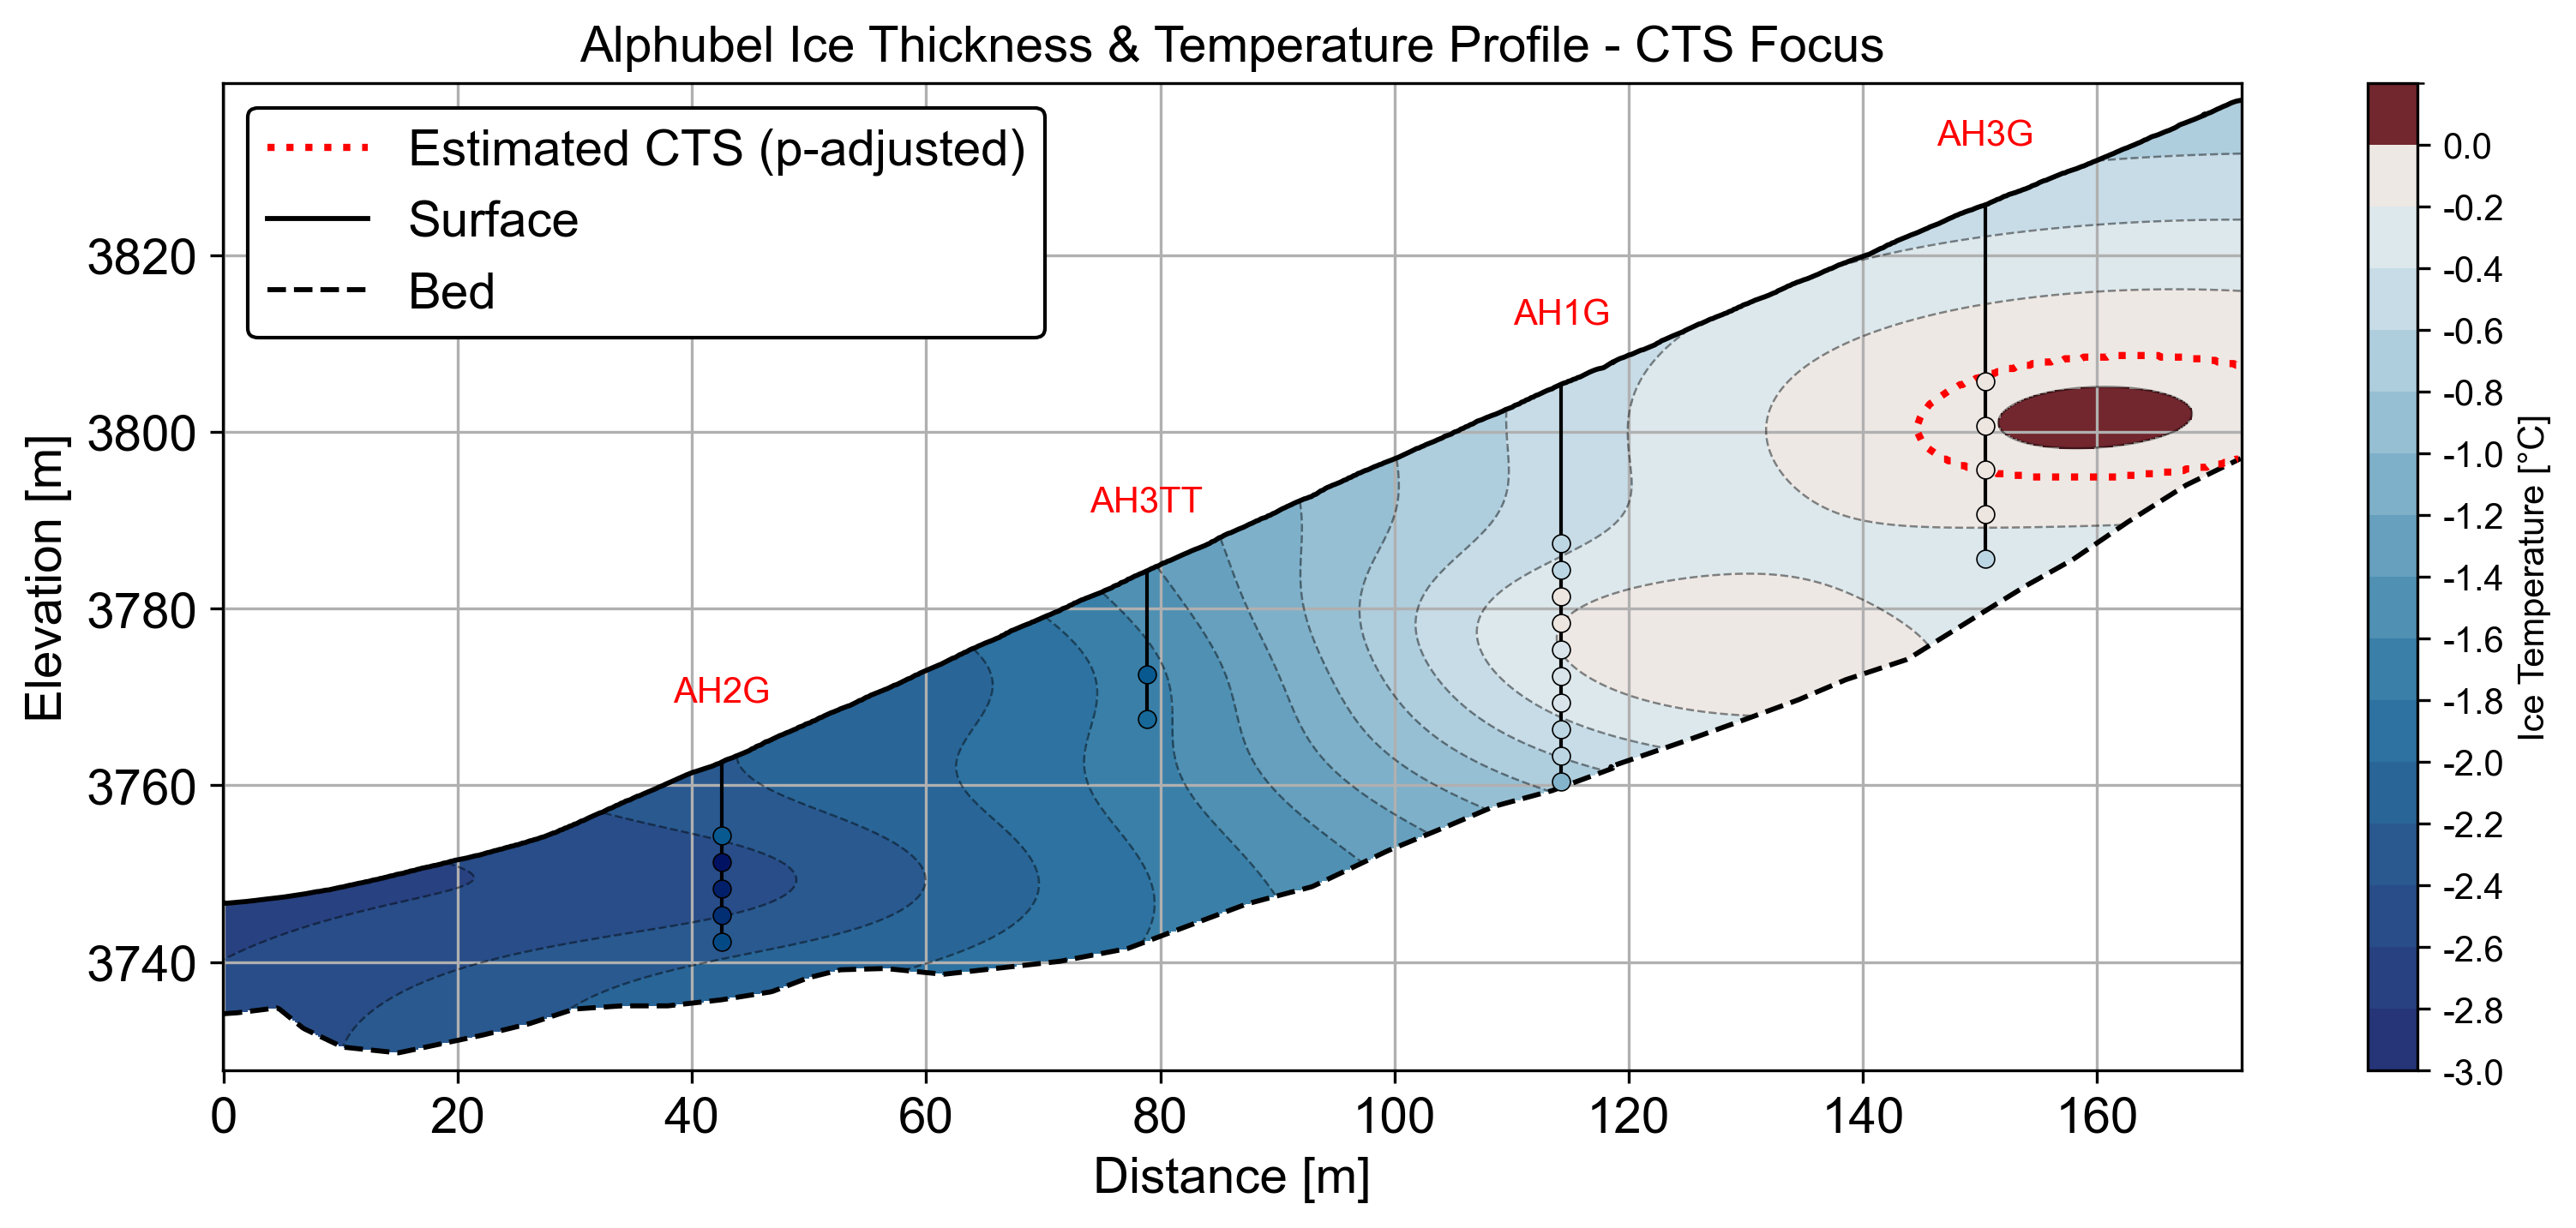

In [7]:
fig, ax = gprp.plot_icetemp_profile(
    profile_df=prof_AH,
    borehole_coords_df=borehole_coordinates,
    temp_data_dict=temp_data_dict_AH,
    depth_dict=depth_dict_AH,
    title="Alphubel Ice Thickness & Temperature Profile - CTS Focus",
    flip=False,          # or 'auto'
    n_depth=400,
    n_elev=600,
    temp_step=0.2,
    plot_contours=True,
    break_threshold=50.0,  # optional (default 50.0)
    smooth_sigma=0.0,      # increase (e.g. 20) to smooth surface/bed & CTS mask
    show_cts=True,
    adjust_cts_for_pressure=True,
    cts_tol=0.03
)

## Plot Chessjen interpolated englacial temperature profile

In [8]:
# Create the input dictionaries
thermistor_data_CJ = {
    'CJ1G': CJ1G_data,
    'CJ2G': CJ2G_data, 
    'CJ1TT': CJ1TT_data,
    'CJ2TT': CJ2TT_data
}

depth_data_CJ = {
    'CJ1G': CJ1G_depths,
    'CJ2G': CJ2G_depths,
    'CJ1TT': CJ1TT_depths,
    'CJ2TT': CJ2TT_depths
}

# Extract temperature and depth dictionaries
temp_data_dict_CJ, depth_dict_CJ = create_temp_depth_dicts(thermistor_data_CJ, depth_data_CJ)

CJ1G: 10 thermistors
  #1: -0.960°C at 11.3 m
  #2: -0.770°C at 14.3 m
  #3: -0.520°C at 17.3 m
  #4: -0.390°C at 20.3 m
  #5: -0.270°C at 23.3 m
  #6: -0.230°C at 26.3 m
  #7: -0.200°C at 29.3 m
  #8: -0.050°C at 32.3 m
  #9: -0.020°C at 35.3 m
  #10: 0.030°C at 38.3 m
CJ2G: 5 thermistors
  #1: -1.330°C at 7.0 m
  #2: -1.280°C at 9.5 m
  #3: -0.950°C at 12.0 m
  #4: -0.670°C at 14.5 m
  #5: 0.060°C at 17.0 m
CJ1TT: 2 thermistors
  white probe: -3.430°C at 4.1 m
  black probe: -1.050°C at 9.1 m
CJ2TT: 2 thermistors
  white probe: -2.420°C at 5.48 m
  black probe: -1.180°C at 10.48 m


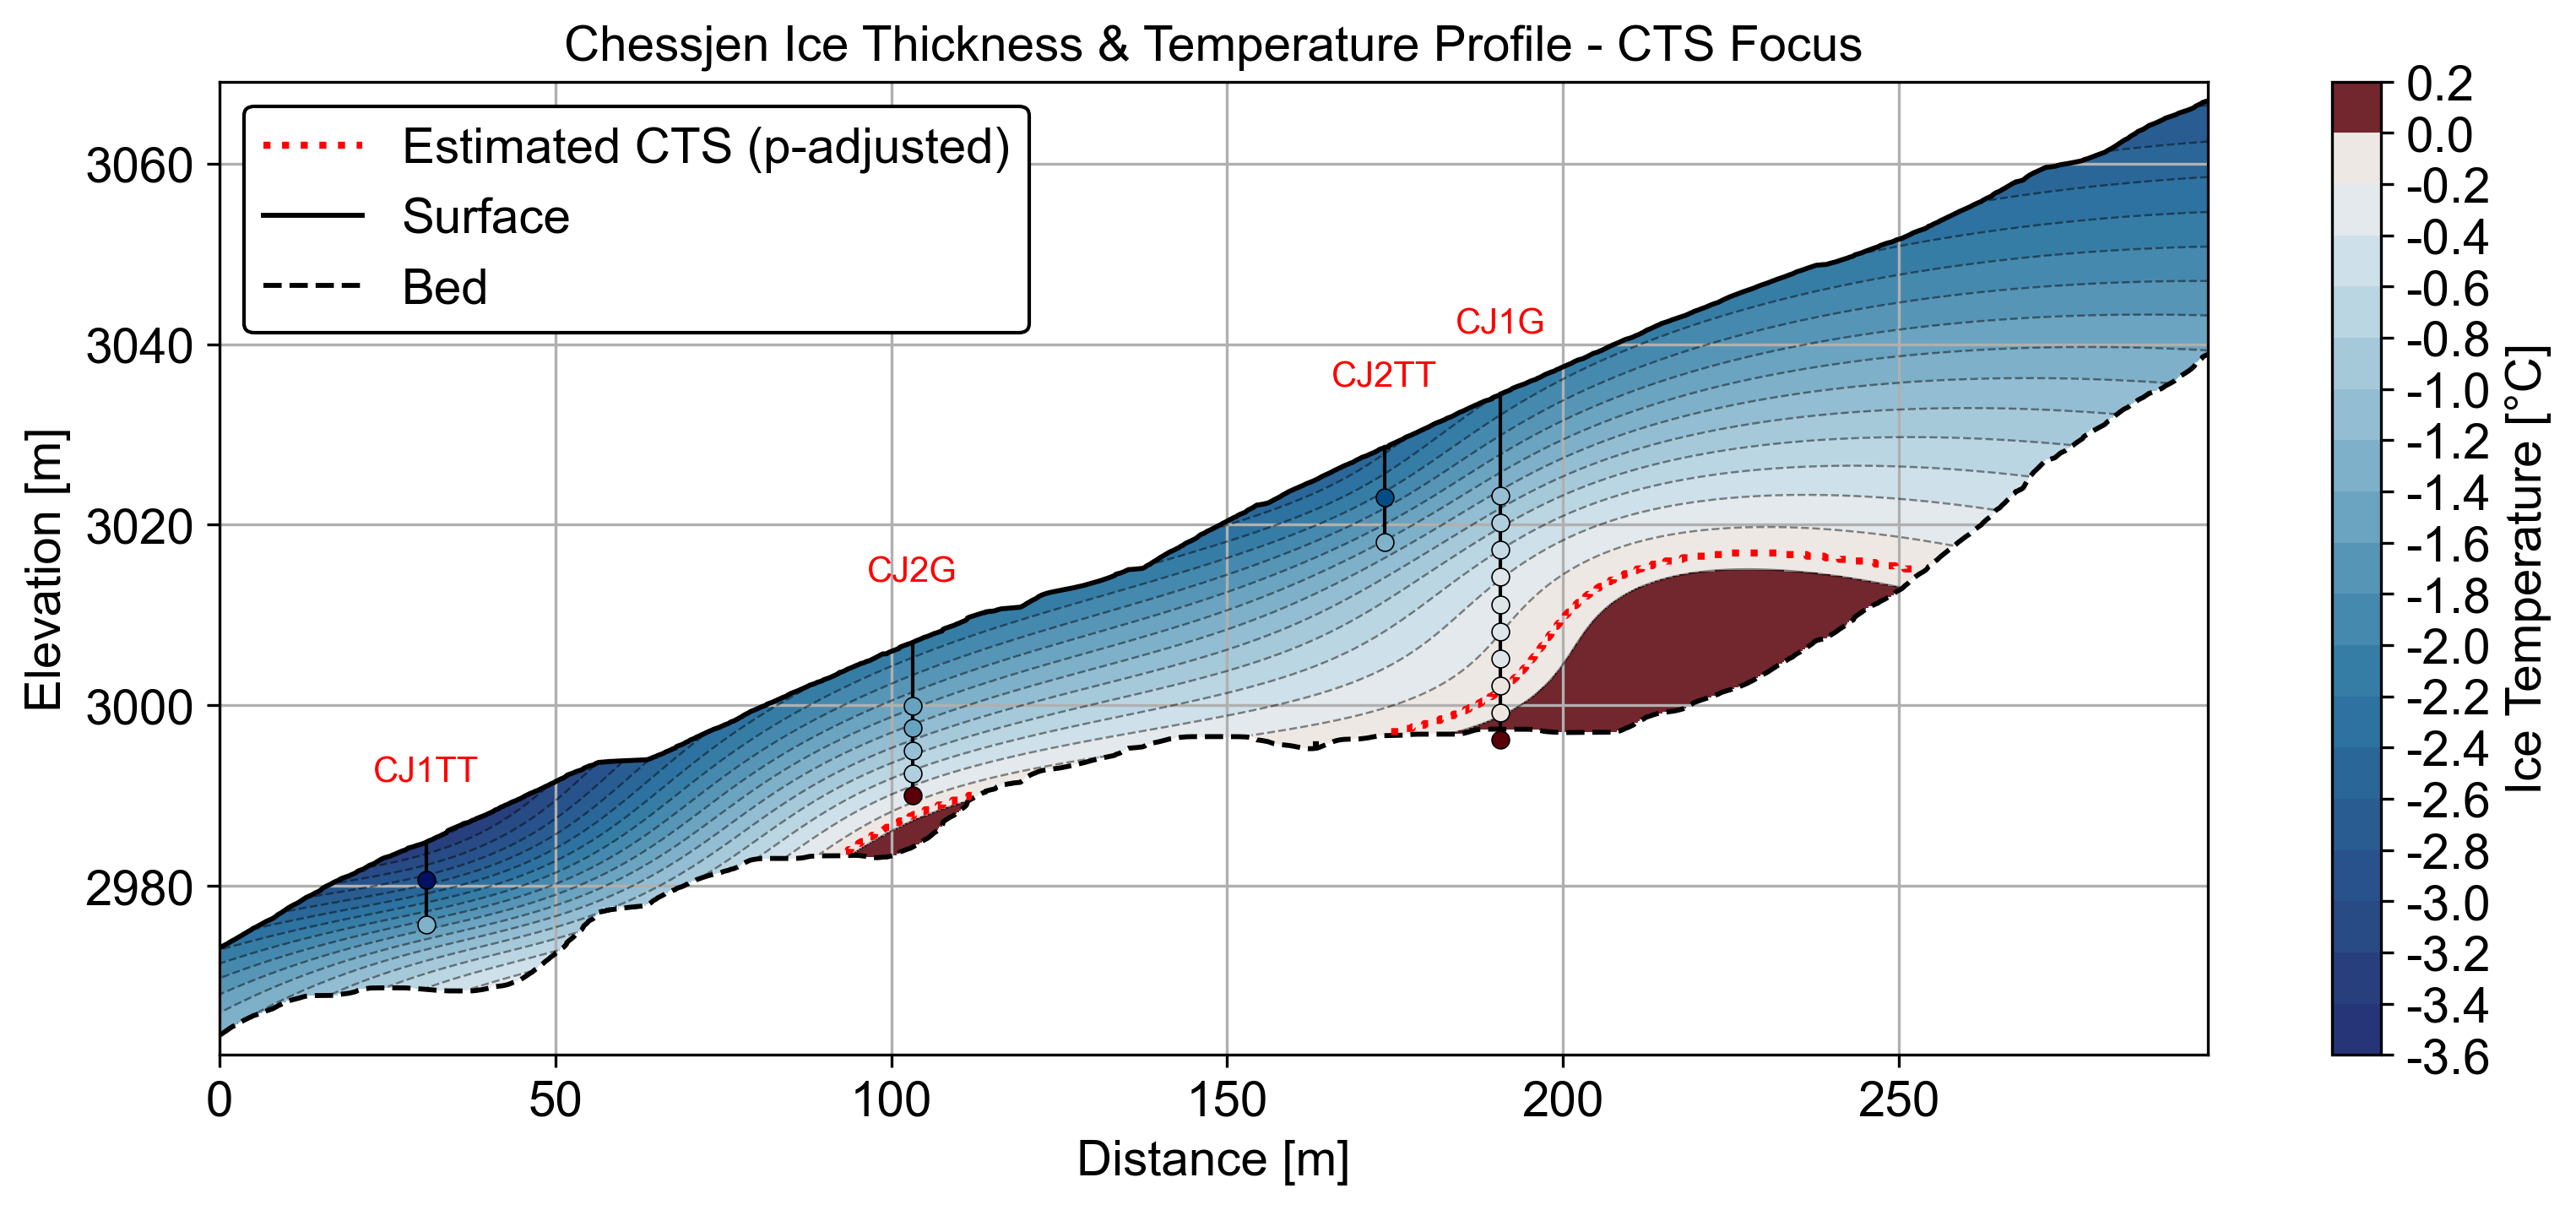

In [9]:
# plot Chessjen profile from borehole temperature data
fig, ax = gprp.plot_icetemp_profile(
    profile_df=prof_cj,
    borehole_coords_df=borehole_coordinates,
    temp_data_dict=temp_data_dict_CJ,
    depth_dict=depth_dict_CJ,
    title="Chessjen Ice Thickness & Temperature Profile - CTS Focus",
    flip=True,
    n_depth=400,
    n_elev=600,
    temp_step=0.2,
    plot_contours=True,
    break_threshold=10.0,
    smooth_sigma=50.0,
    show_cts=True,
    adjust_cts_for_pressure=True,
    cts_tol=0.05
)

## Plot Hohsaas interpolated englacial temperature profile

2 Profiles: 
1. Line 39 (thermistors HS1G and HS2TT)
2. Line 40 (thermistors HS2G and HS1TT)

In [10]:
# Create the input dictionaries for Hohsaas
thermistor_data_HS1 = {
    'HS1G': HS1G_data,
    'HS2TT': HS2TT_data
}

thermistor_data_HS2 = {
    'HS2G': HS2G_data,
    'HS1TT': HS1TT_data
}

depth_data_HS1 = {
    'HS1G': HS1G_depths,
    'HS2TT': HS2TT_depths
}

depth_data_HS2 = {
    'HS2G': HS2G_depths,
    'HS1TT': HS1TT_depths
}

# Extract temperature and depth dictionaries
temp_data_dict_HS1, depth_dict_HS1 = create_temp_depth_dicts(thermistor_data_HS1, depth_data_HS1)
temp_data_dict_HS2, depth_dict_HS2 = create_temp_depth_dicts(thermistor_data_HS2, depth_data_HS2)

HS1G: 10 thermistors
  #1: -0.450°C at 2.0 m
  #2: -0.600°C at 5.0 m
  #3: -0.390°C at 8.0 m
  #4: -0.150°C at 11.0 m
  #5: -0.080°C at 14.0 m
  #6: -0.010°C at 17.0 m
  #7: 0.010°C at 20.0 m
  #8: 0.030°C at 23.0 m
  #9: -0.000°C at 26.0 m
  #10: -0.040°C at 29.0 m
HS2TT: 2 thermistors
  white probe: -1.460°C at 7.5 m
  black probe: -0.610°C at 12.5 m
HS2G: 5 thermistors
  #1: -1.080°C at 1.5 m
  #2: -0.770°C at 6.5 m
  #3: -0.480°C at 11.5 m
  #4: -0.250°C at 16.5 m
  #5: -0.000°C at 21.5 m
HS1TT: 2 thermistors
  white probe: -1.280°C at 8.3 m
  black probe: -0.470°C at 13.3 m


### GPR Line 39

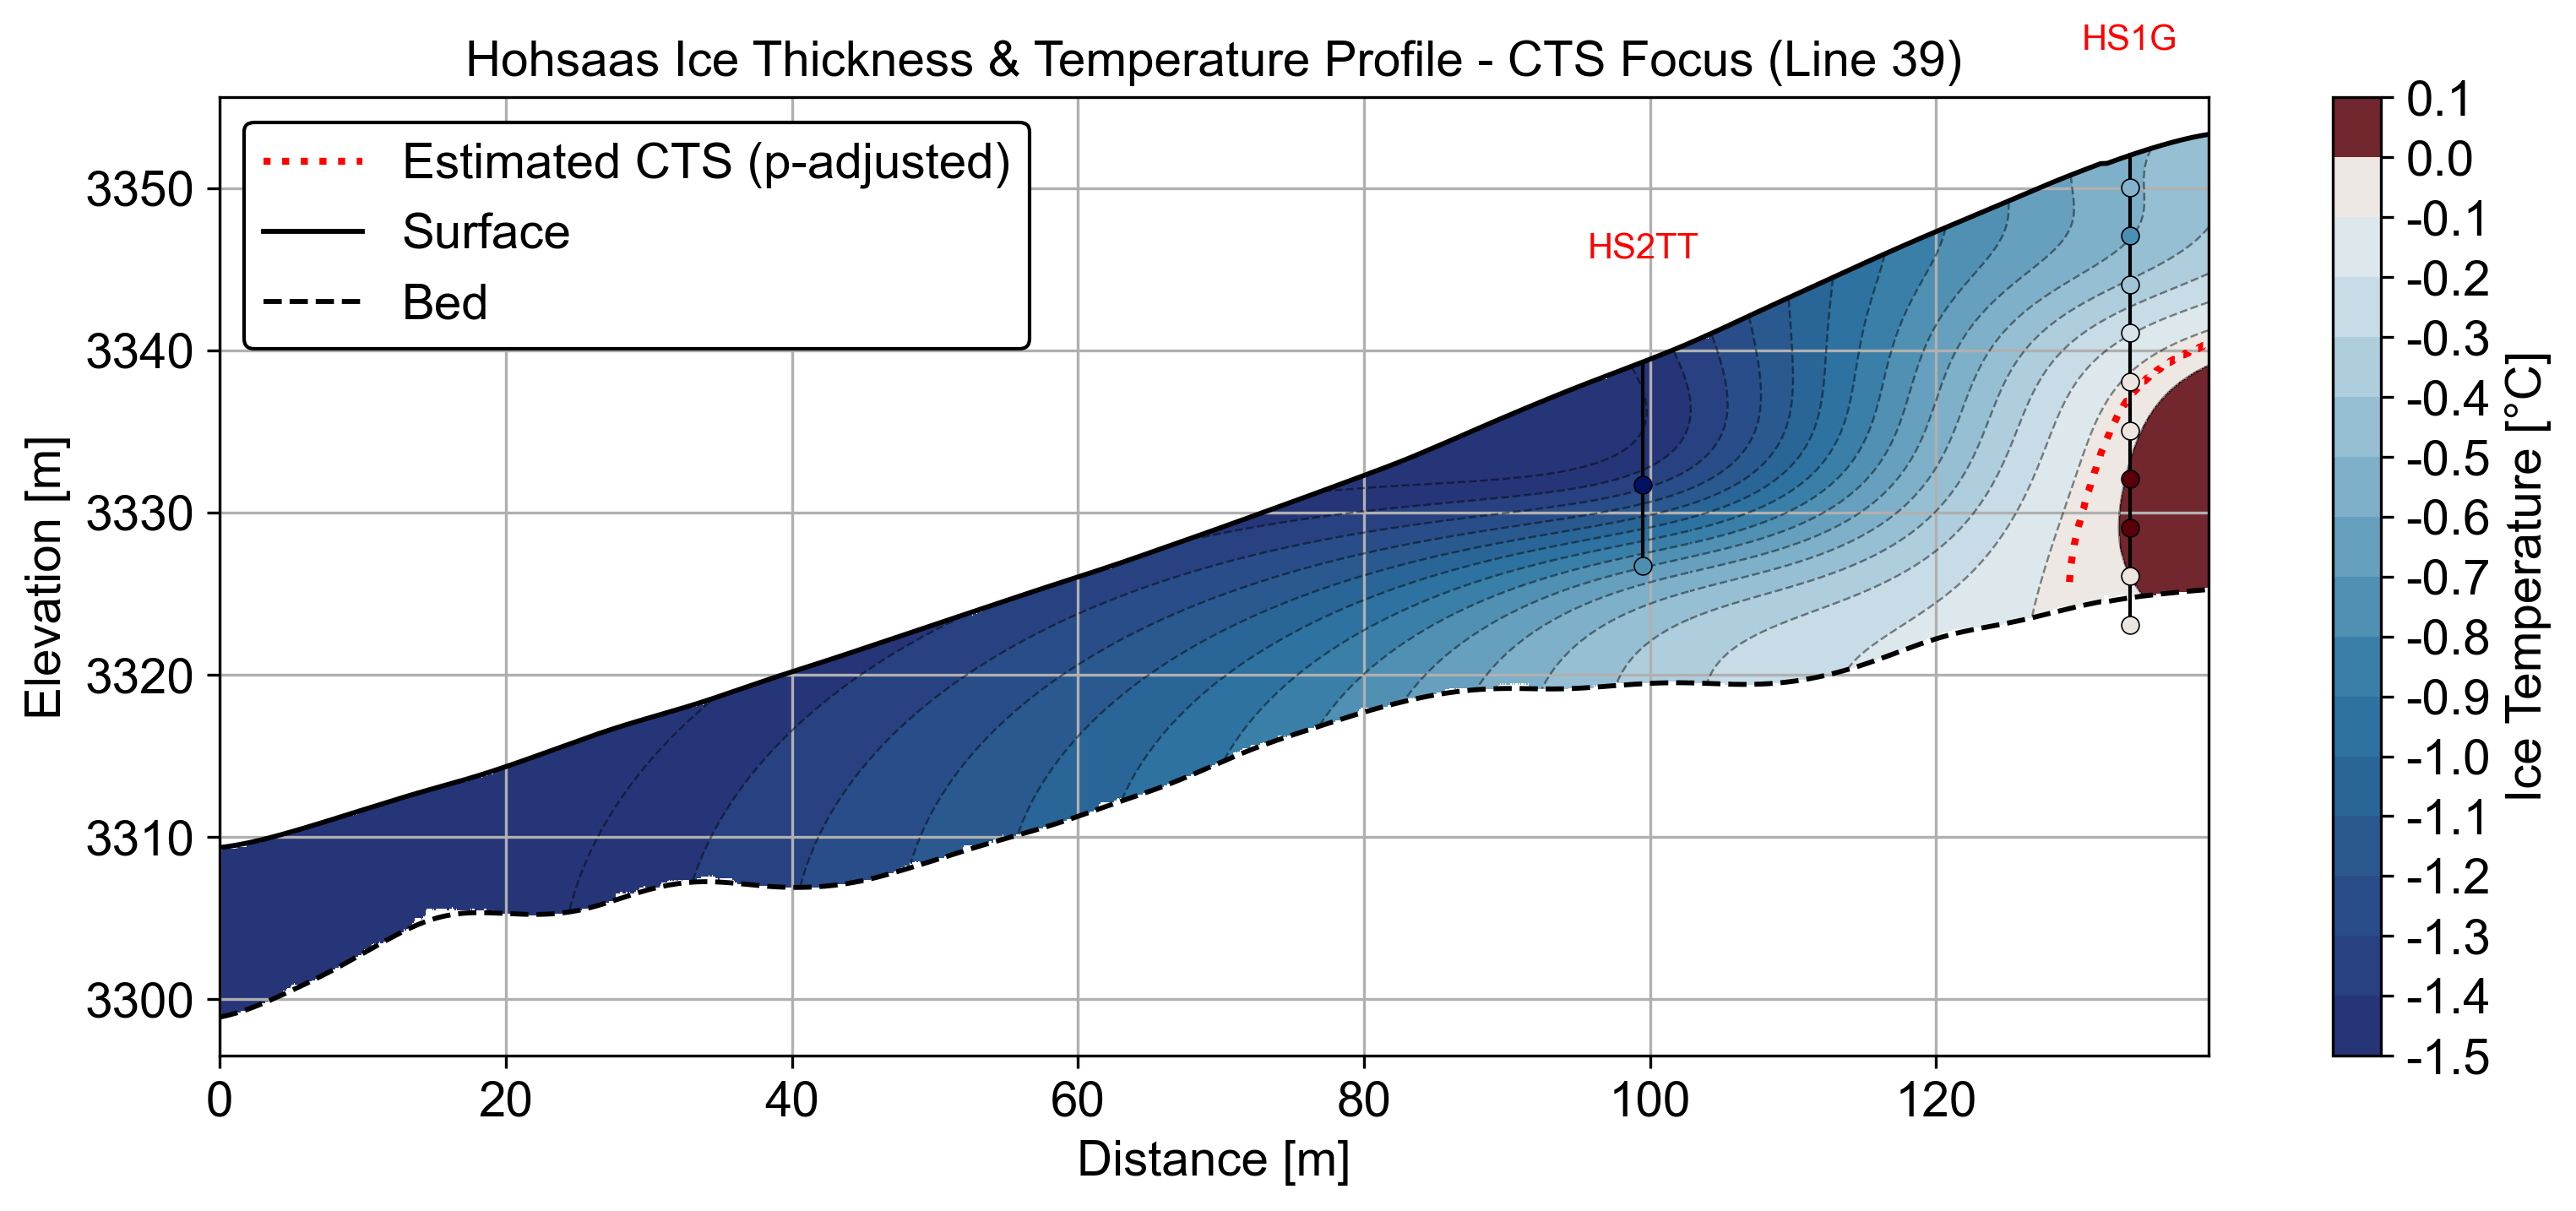

In [13]:
# plot Hohsaas profile from borehole temperature data (GPR Line 39)
fig, ax = gprp.plot_icetemp_profile(
    profile_df=prof_hs1,
    borehole_coords_df=borehole_coordinates,
    temp_data_dict=temp_data_dict_HS1,
    depth_dict=depth_dict_HS1,
    title="Hohsaas Ice Thickness & Temperature Profile - CTS Focus (Line 39)",
    flip=False,
    n_depth=400,      # Higher resolution
    n_elev=600,       # Higher resolution
    plot_contours=True,
    break_threshold=10.0,
    smooth_sigma=50.0,   # smoothing for outlines / CTS mask
    temp_step=0.1,
    show_cts=True,
    adjust_cts_for_pressure=True,
    cts_tol=0.05
    # detect_internal_temperate=True,  # uncomment if multilayer CTS enabled
)

### GPR Line 40

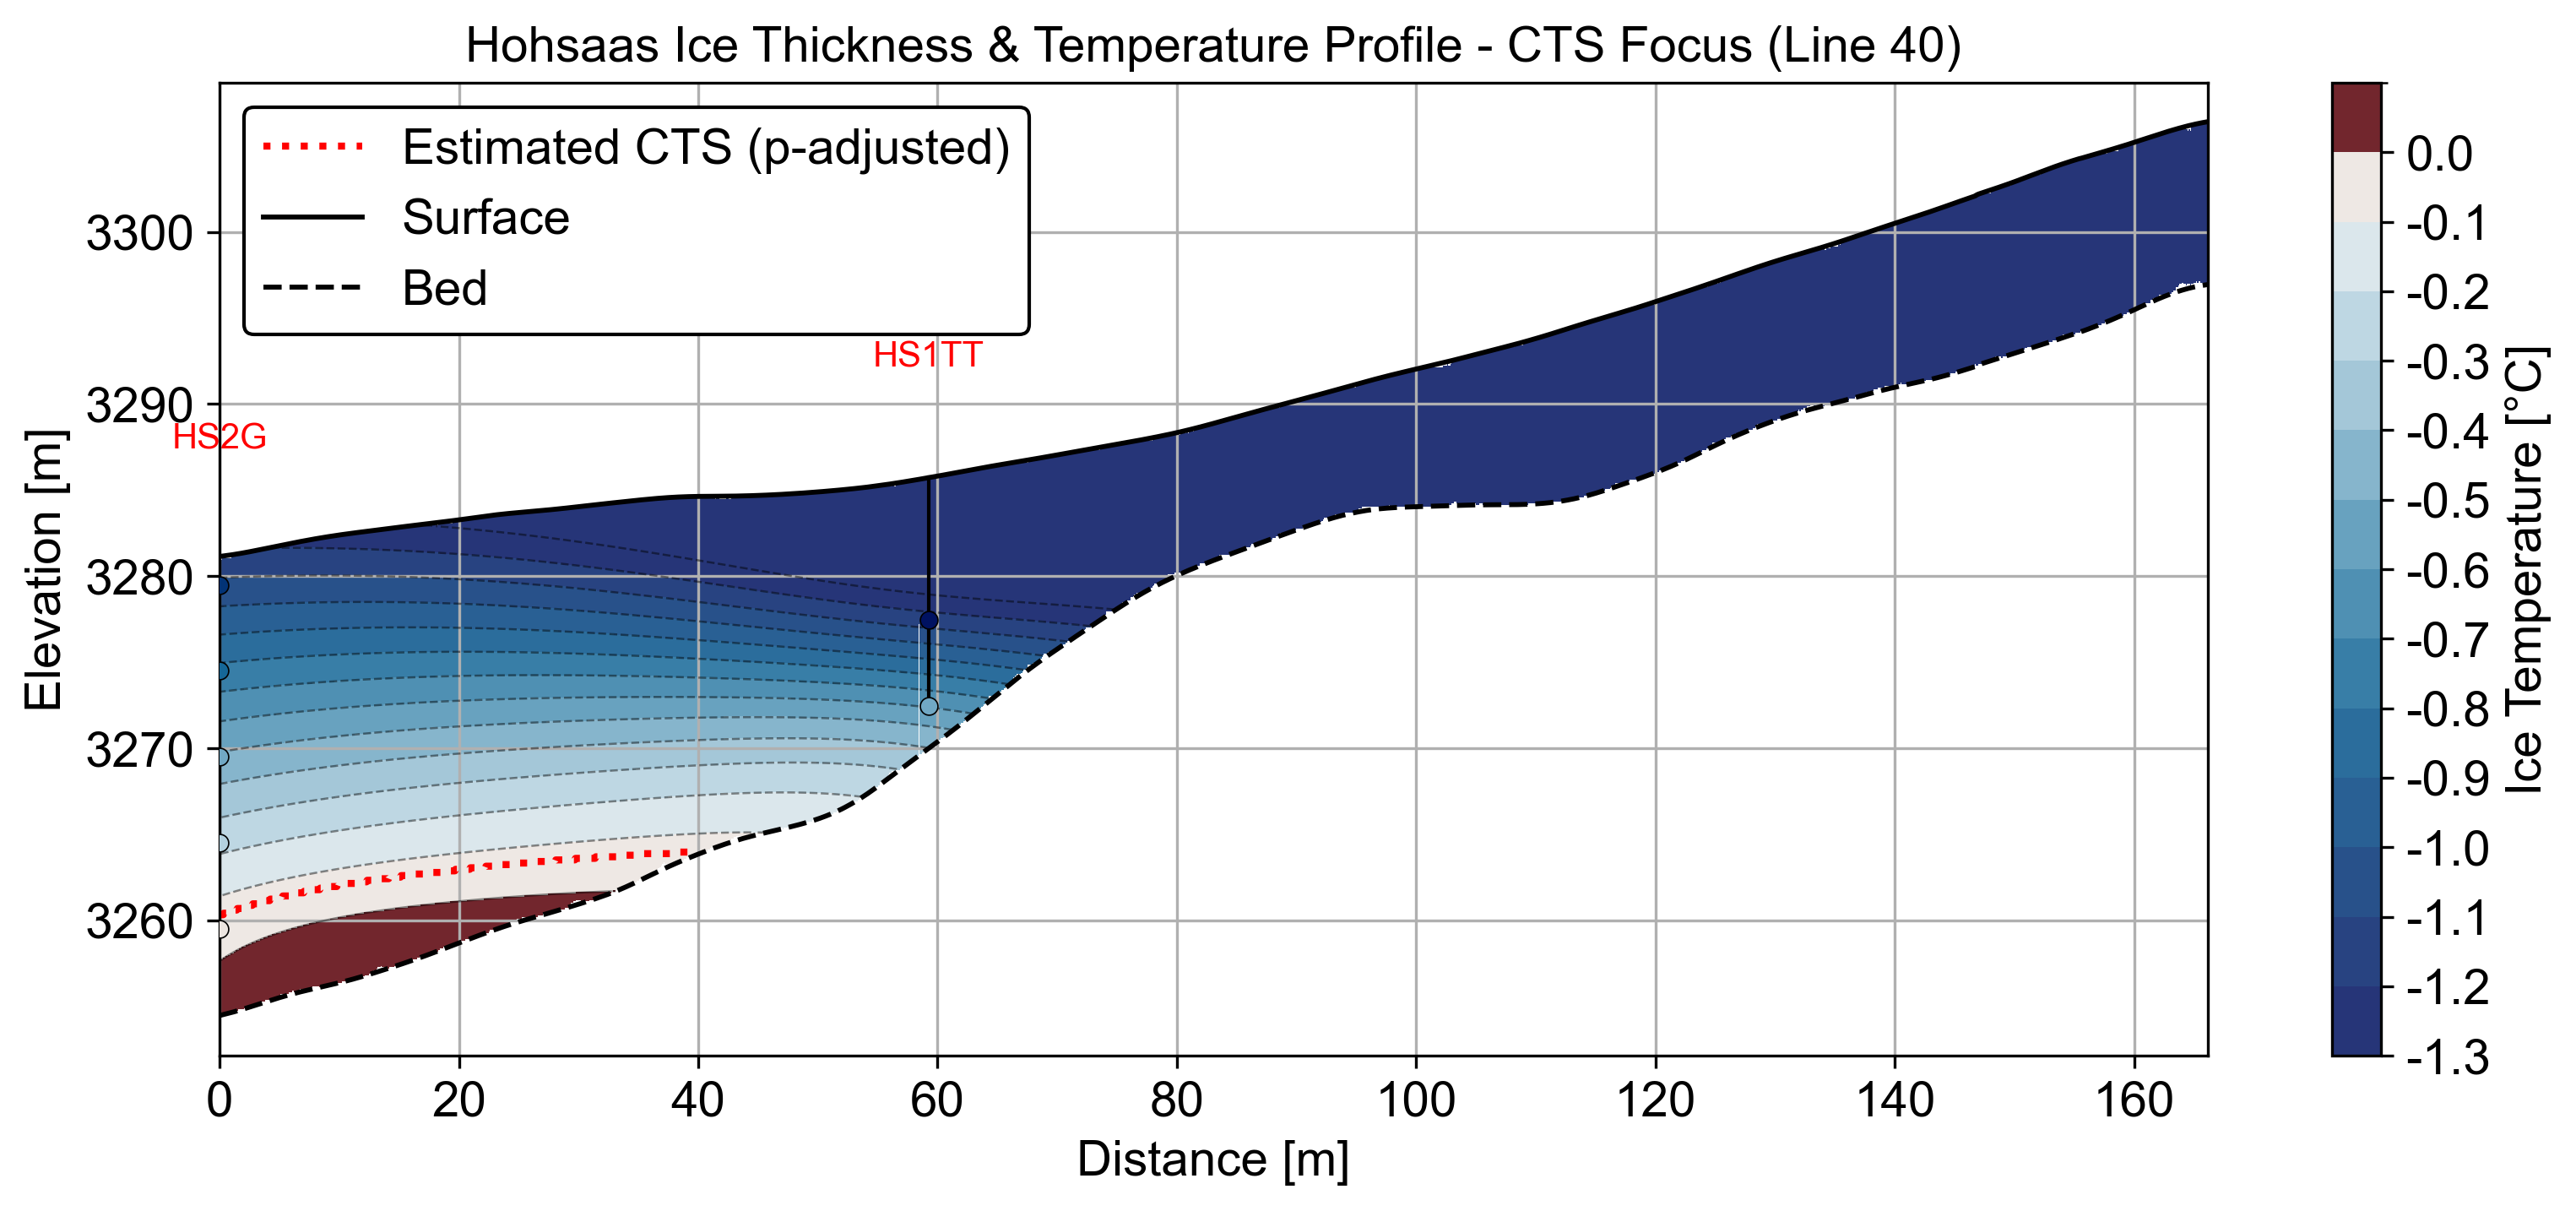

In [15]:
# plot Hohsaas profile from borehole temperature data (GPR Line 40)
fig, ax = gprp.plot_icetemp_profile(
    profile_df=prof_hs2,
    borehole_coords_df=borehole_coordinates,
    temp_data_dict=temp_data_dict_HS2,
    depth_dict=depth_dict_HS2,
    title="Hohsaas Ice Thickness & Temperature Profile - CTS Focus (Line 40)",
    flip=False,
    n_depth=400,
    n_elev=600,
    plot_contours=True,
    break_threshold=10.0,
    smooth_sigma=50.0,
    temp_step=0.1,
    show_cts=True,
    adjust_cts_for_pressure=True,
    cts_tol=0.05
    # detect_internal_temperate=True,  # uncomment if multilayer CTS enabled
)